In [1]:
from oligo_maldi.experiment import Experiment
from oligo_maldi.analytes import Oligo

Determination of memory status is not supported on this 
 platform, measuring for memoryleaks will never fail


Samples will be automatically parsed from data when an Experiment is defined

In [2]:
data = "/Users/mitchsyberg-olsen/github/oligo_maldi/data/experiment_1"
run1 = Experiment(data_folder=data)


Samples can be accessed from the Experiment object using Experiment.samples[well]

In [3]:
demo_sample = run1.samples['D9']

Define the oligos that will be in the sample

In [4]:
# Calibration oligos
MJS296 = Oligo(name='MJS296', seq='ACGTACGTACG', five_prime_end='OH', ps_bonds=0, error=0)
MJS297 = Oligo(name='MJS297', seq='ACGTACGTACGT', five_prime_end='OH', ps_bonds=0, error=0)
MJS392 = Oligo(name='MJS392', seq='ACGTACGTACGTACGT', five_prime_end='OH', ps_bonds=0, error=0)
MJS298 = Oligo(name='MJS298', seq='ACGTACGTACGTACGTACGT', five_prime_end='OH', ps_bonds=0, error=0)
oligos_calibration = [MJS296,MJS297,MJS298,MJS392]

demo_sample.analytes = [] # reset mois
demo_sample.analytes.extend(oligos_calibration)

Samples contain metadata

In [5]:
metadata = [demo_sample.file, demo_sample.chip, demo_sample.well]
print(*metadata, sep="\n")

2026_02_25_0001_0_D9_1.txt
0
D9


In [6]:
mois = [f"{moi.name}: {str(moi)}" for moi in demo_sample.analytes]
print(*mois, sep="\n")

MJS296: 5' (HO)-ACGTACGTACG 3'
MJS297: 5' (HO)-ACGTACGTACGT 3'
MJS298: 5' (HO)-ACGTACGTACGTACGTACGT 3'
MJS392: 5' (HO)-ACGTACGTACGTACGT 3'


(<Figure size 800x300 with 1 Axes>,
 <Axes: title={'center': 'Sample: D9'}, xlabel='m/z', ylabel='Ion count'>)

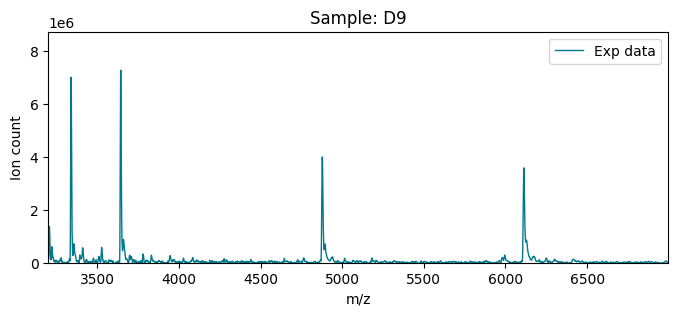

In [8]:
#general purpose plotting function for an individual sample
demo_sample.plot()

(<Figure size 1600x300 with 1 Axes>,
 <Axes: title={'center': 'Distance between adjacent mz points in spectrum data'}, xlabel='m/z', ylabel='Distance (daltons)'>)

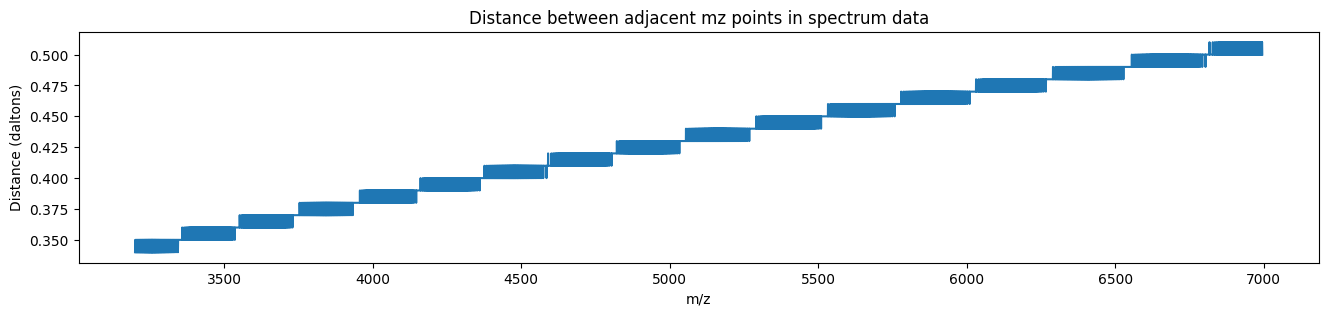

In [7]:
# shows the resolution of the reading across the entire spectra
demo_sample.plot_distance_between_points()

(<Figure size 800x300 with 1 Axes>,
 <Axes: title={'center': 'Signal intensity distribution'}, xlabel='Percent of data', ylabel='Relative signal'>)

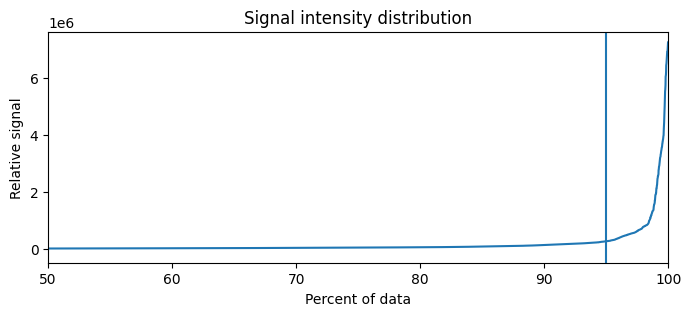

In [9]:
# Same as Experiment.sorted_signal_plot() but for only 1 trace
demo_sample.sorted_signal_plot()

(<Figure size 800x300 with 1 Axes>,
 <Axes: title={'center': 'MJS298, monoisotopic mass = 6115.064, charge = +1'}, xlabel='m/z', ylabel='Relative intensity (au)'>)

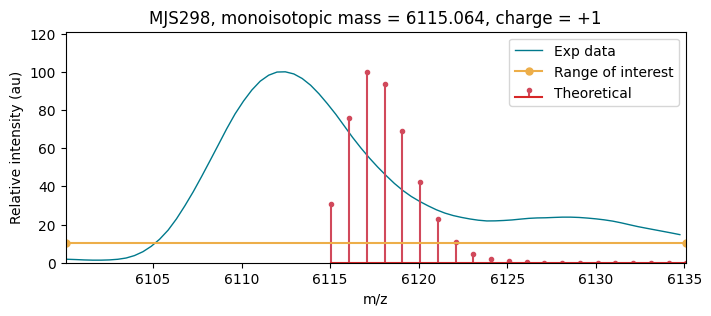

In [10]:
# you can overlay experimental and theoretical data for any MOI
demo_sample.plot_analyte(moi=MJS298, filtered=False)

(<Figure size 800x300 with 1 Axes>,
 <Axes: title={'center': 'MJS298, monoisotopic mass = 6115.064, charge = +1'}, xlabel='m/z', ylabel='Relative intensity (au)'>)

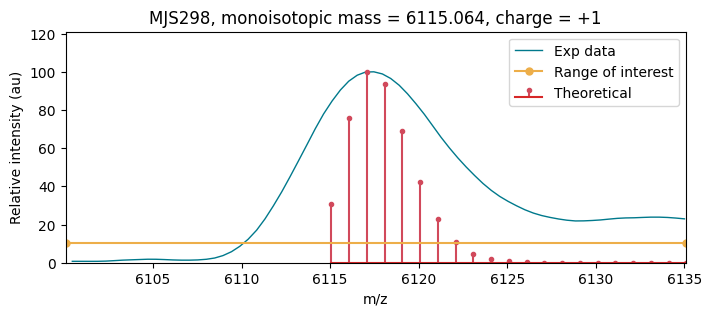

In [15]:
# if the calibration is off, it's possible to adjust sample spectra individually using mz_offset and recalc_mz()
demo_sample.mz_offset = 5
demo_sample.recalc_mz()
demo_sample.plot_analyte(moi=MJS298, filtered=False)

(<Figure size 800x300 with 1 Axes>,
 <Axes: title={'center': 'Sample: D9'}, xlabel='m/z', ylabel='Ion count'>)

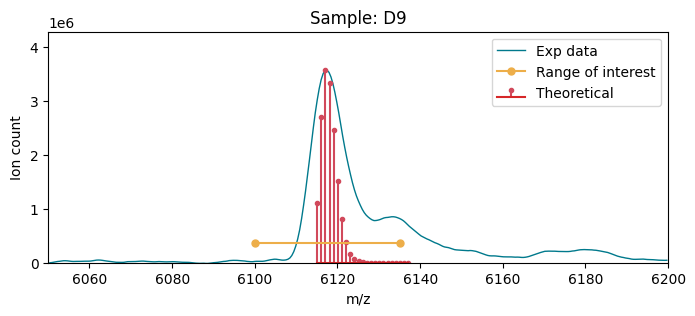

In [16]:
# you can also access theoretical distributions in the plot() function
demo_sample.plot(xlim=(6050,6200), theoretical_dist=True)